# Phân tích doanh số bán hàng ô tô Ford (2023-2025)

## Mục tiêu
- Khám phá bộ dữ liệu doanh số Ford giai đoạn 2023-2025.
- Trực quan hóa xu hướng bán hàng theo thời gian, sản phẩm và khu vực.
- Xây dựng mô hình dự báo ngắn hạn có xét yếu tố mùa vụ.

In [4]:
# Mục đích: Nạp toàn bộ thư viện phân tích và trực quan hóa, đồng thời chuẩn hóa giao diện biểu đồ (kích thước, font, linewidth) để các hình trong notebook đồng nhất và dễ đọc.
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from statsmodels.tools.sm_exceptions import ConvergenceWarning

warnings.filterwarnings('ignore', category=ConvergenceWarning)

# Thiết lập style chung cho toàn bộ notebook
plt.style.use('ggplot')
plt.rcParams['figure.figsize'] = (11, 6)
plt.rcParams['font.size'] = 11
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 12
plt.rcParams['legend.fontsize'] = 10
plt.rcParams['lines.linewidth'] = 2
plt.rcParams['font.family'] = 'DejaVu Sans'

In [5]:
# Đọc dữ liệu từ file Excel đã làm sạch
file_path = 'Ford_Sales_2023_2025_cleaned_v2.xlsx'
df = pd.read_excel(file_path, sheet_name='CleanedData')

print('Lưu ý: Bộ dữ liệu không có cột giá bán, vì vậy doanh số được phân tích theo chỉ số  là sản lượng xe bán.')
display(df.head())

Lưu ý: Bộ dữ liệu không có cột giá bán, vì vậy doanh số được phân tích theo chỉ số  là sản lượng xe bán.


,Năm,Quý,Tháng,STT,Tên KH,Dòng xe,Màu,Khu vực,Số lượng (xe)
0,2023,Q1,1,5,Lê Long,Territory,Xanh,HCM,1
1,2023,Q1,1,16,Hoàng Tuấn,Ranger,Trắng,HCM,2
2,2023,Q1,1,20,Phan Long,Ranger,Xanh,Đà Nẵng,2
3,2023,Q1,1,24,Trần Nam,Explorer,Đỏ,Hà Nội,1
4,2023,Q1,1,27,Lê Quân,Ranger,Đen,Hải Phòng,2


In [6]:
# Khám phá tổng quan dữ liệu
print('Thông tin dữ liệu:')
df.info()

print('\nThống kê mô tả các cột:')
display(df.describe(include='all').transpose())

Thông tin dữ liệu:
<class 'pandas.DataFrame'>
RangeIndex: 2109 entries, 0 to 2108
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype
---  ------         --------------  -----
 0   Năm            2109 non-null   int64
 1   Quý            2109 non-null   str  
 2   Tháng          2109 non-null   int64
 3   STT            2109 non-null   int64
 4   Tên KH         2109 non-null   str  
 5   Dòng xe        2109 non-null   str  
 6   Màu            2109 non-null   str  
 7   Khu vực        2109 non-null   str  
 8   Số lượng (xe)  2109 non-null   int64
dtypes: int64(4), str(5)
memory usage: 148.4 KB

Thống kê mô tả các cột:


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Năm,2109.0,NaN,NaN,NaN,2024.100047,0.799042,2023.0,2023.0,2024.0,2025.0,2025.0
Quý,2109,4,Q3,531,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Tháng,2109.0,NaN,NaN,NaN,6.5211,3.450402,1.0,4.0,7.0,10.0,12.0
STT,2109.0,NaN,NaN,NaN,358.656235,213.224427,1.0,176.0,352.0,529.0,794.0
Tên KH,2109,24,Trần Cường,115,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Dòng xe,2109,4,Territory,544,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Màu,2109,5,Đen,458,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Khu vực,2109,5,Đà Nẵng,441,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Số lượng (xe),2109.0,NaN,NaN,NaN,1.985301,0.816848,1.0,1.0,2.0,3.0,3.0


## 1. Tổng quan doanh số theo thời gian

## Biểu đồ 1 - Doanh số theo tháng và năm (Line Chart)

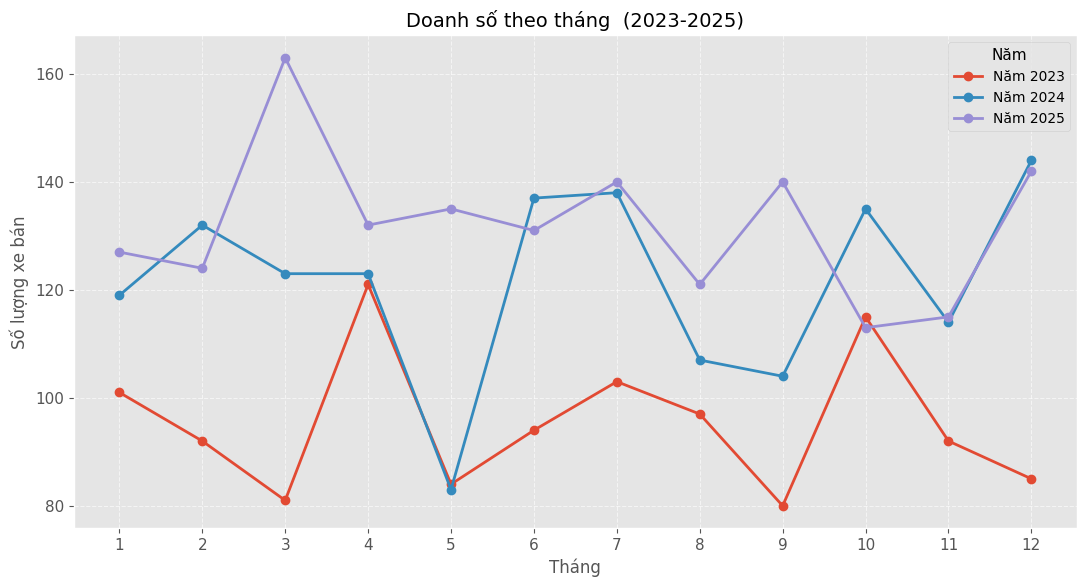

In [7]:
# Mục đích: Gom nhóm dữ liệu theo cặp Năm-Tháng để tính tổng số xe bán, sau đó pivot thành bảng theo tháng và vẽ line chart nhiều đường nhằm so sánh xu hướng giữa các năm.
sales_by_year_month = (
    df.groupby(['Năm', 'Tháng'], as_index=False)['Số lượng (xe)']
      .sum()
)

pivot_year_month = sales_by_year_month.pivot(index='Tháng', columns='Năm', values='Số lượng (xe)').sort_index()

fig, ax = plt.subplots()
for year in pivot_year_month.columns:
    ax.plot(pivot_year_month.index, pivot_year_month[year], marker='o', label=f'Năm {year}')

ax.set_title('Doanh số theo tháng  (2023-2025)')
ax.set_xlabel('Tháng')
ax.set_ylabel('Số lượng xe bán')
ax.legend(title='Năm')
ax.grid(True, linestyle='--', alpha=0.6)
plt.xticks(range(1, 13))
plt.tight_layout()
plt.show()

### Insights - Biểu đồ 1
- Điểm nổi bật: Doanh số theo tháng biến động rõ giữa các năm.
- Xu hướng chính: Có dấu hiệu mùa vụ theo tháng.
- Nguyên nhân có thể: Khuyến mại theo mùa, chu kỳ ra mắt phiên bản, nguồn cung.
- Đề xuất hành động: Lập kế hoạch tồn kho và marketing theo tháng cao điểm.

## Biểu đồ 2 - Doanh số theo năm (Bar Chart)

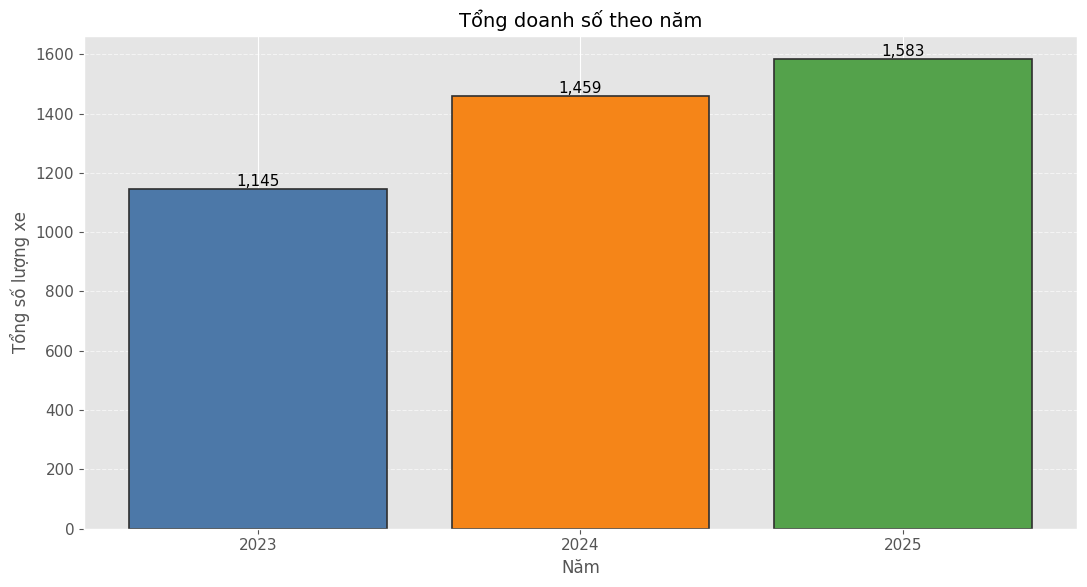

In [8]:
# Mục đích: Tính tổng doanh số từng năm, vẽ biểu đồ cột để nhìn mức tăng/giảm theo năm và gắn nhãn số trực tiếp trên mỗi cột để dễ đọc giá trị tuyệt đối.
sales_by_year = df.groupby('Năm', as_index=False)['Số lượng (xe)'].sum()
fig, ax = plt.subplots()
bars = ax.bar(sales_by_year['Năm'].astype(str), sales_by_year['Số lượng (xe)'], color=['#4C78A8', '#F58518', '#54A24B'], edgecolor='#2F2F2F', linewidth=1.2)
ax.set_title('Tổng doanh số theo năm')
ax.set_xlabel('Năm')
ax.set_ylabel('Tổng số lượng xe')
ax.grid(True, axis='y', linestyle='--', alpha=0.6)
for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, height, f'{int(height):,}', ha='center', va='bottom')
plt.tight_layout()
plt.show()

### Insights - Biểu đồ 2
- Điểm nổi bật: Chênh lệch doanh số giữa các năm đáng kể.
- Xu hướng chính: Nhận diện năm tăng mạnh và năm chững.
- Nguyên nhân có thể: Kinh tế vĩ mô, thay đổi danh mục xe, chính sách bán hàng.
- Đề xuất hành động: Dùng năm tốt làm benchmark KPI và tối ưu nguồn lực.

## Biểu đồ 3 - Doanh số theo quý cho từng năm (Grouped Bar)

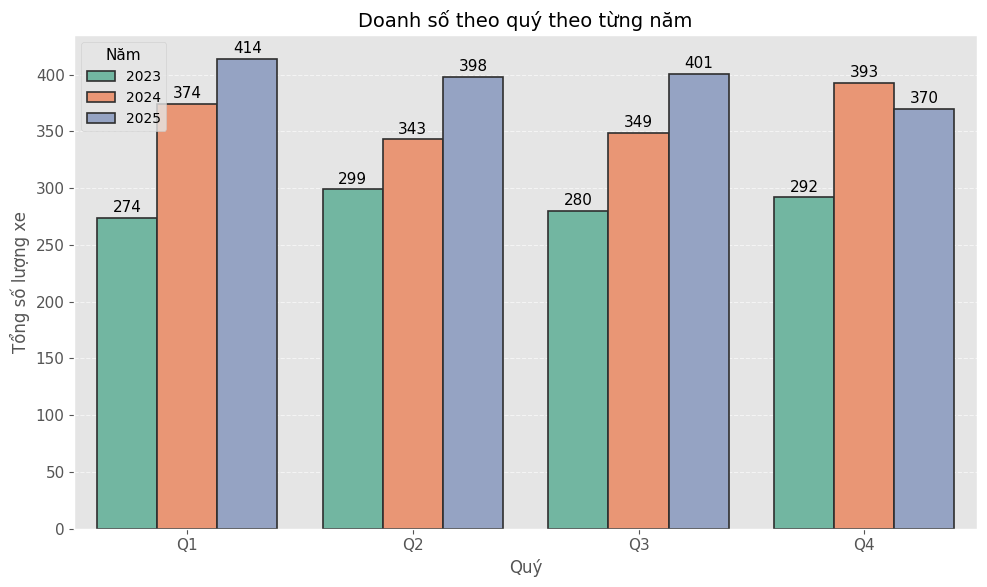

In [9]:
# Mục đích: Chuẩn hóa thứ tự quý Q1-Q4, tổng hợp doanh số theo Năm-Quý và vẽ grouped bar chart để đối chiếu từng quý giữa các năm một cách trực quan.
quarter_order = ['Q1', 'Q2', 'Q3', 'Q4']
year_order = sorted(df['Năm'].dropna().unique())
sales_by_quarter_year = (
    df.groupby(['Năm', 'Quý'], as_index=False)['Số lượng (xe)']
      .sum()
)
sales_by_quarter_year['Quý'] = pd.Categorical(sales_by_quarter_year['Quý'], categories=quarter_order, ordered=True)
sales_by_quarter_year['Năm'] = pd.Categorical(sales_by_quarter_year['Năm'], categories=year_order, ordered=True)
sales_by_quarter_year = sales_by_quarter_year.sort_values(['Quý', 'Năm'])
fig, ax = plt.subplots(figsize=(10, 6))
sns.barplot(data=sales_by_quarter_year, x='Quý', y='Số lượng (xe)', hue='Năm', palette='Set2', edgecolor='#2F2F2F', linewidth=1.2, ax=ax)
ax.set_title('Doanh số theo quý theo từng năm')
ax.set_xlabel('Quý')
ax.set_ylabel('Tổng số lượng xe')
ax.grid(True, axis='y', linestyle='--', alpha=0.6)
ax.legend(title='Năm')
for container in ax.containers:
    ax.bar_label(container, fmt='%.0f', padding=2)
plt.tight_layout()
plt.show()

### Insights - Biểu đồ 3
- Điểm nổi bật: Doanh số giữa các quý không đồng đều.
- Xu hướng chính: Có quý cao điểm/thấp điểm theo năm.
- Nguyên nhân có thể: Chương trình ưu đãi, chu kỳ giao xe, hành vi mua theo mùa.
- Đề xuất hành động: Phân bổ tồn kho và marketing theo quý.

## 2. Phân tích sản phẩm

## Biểu đồ 4 - Doanh số các dòng xe theo từng tháng trong các năm

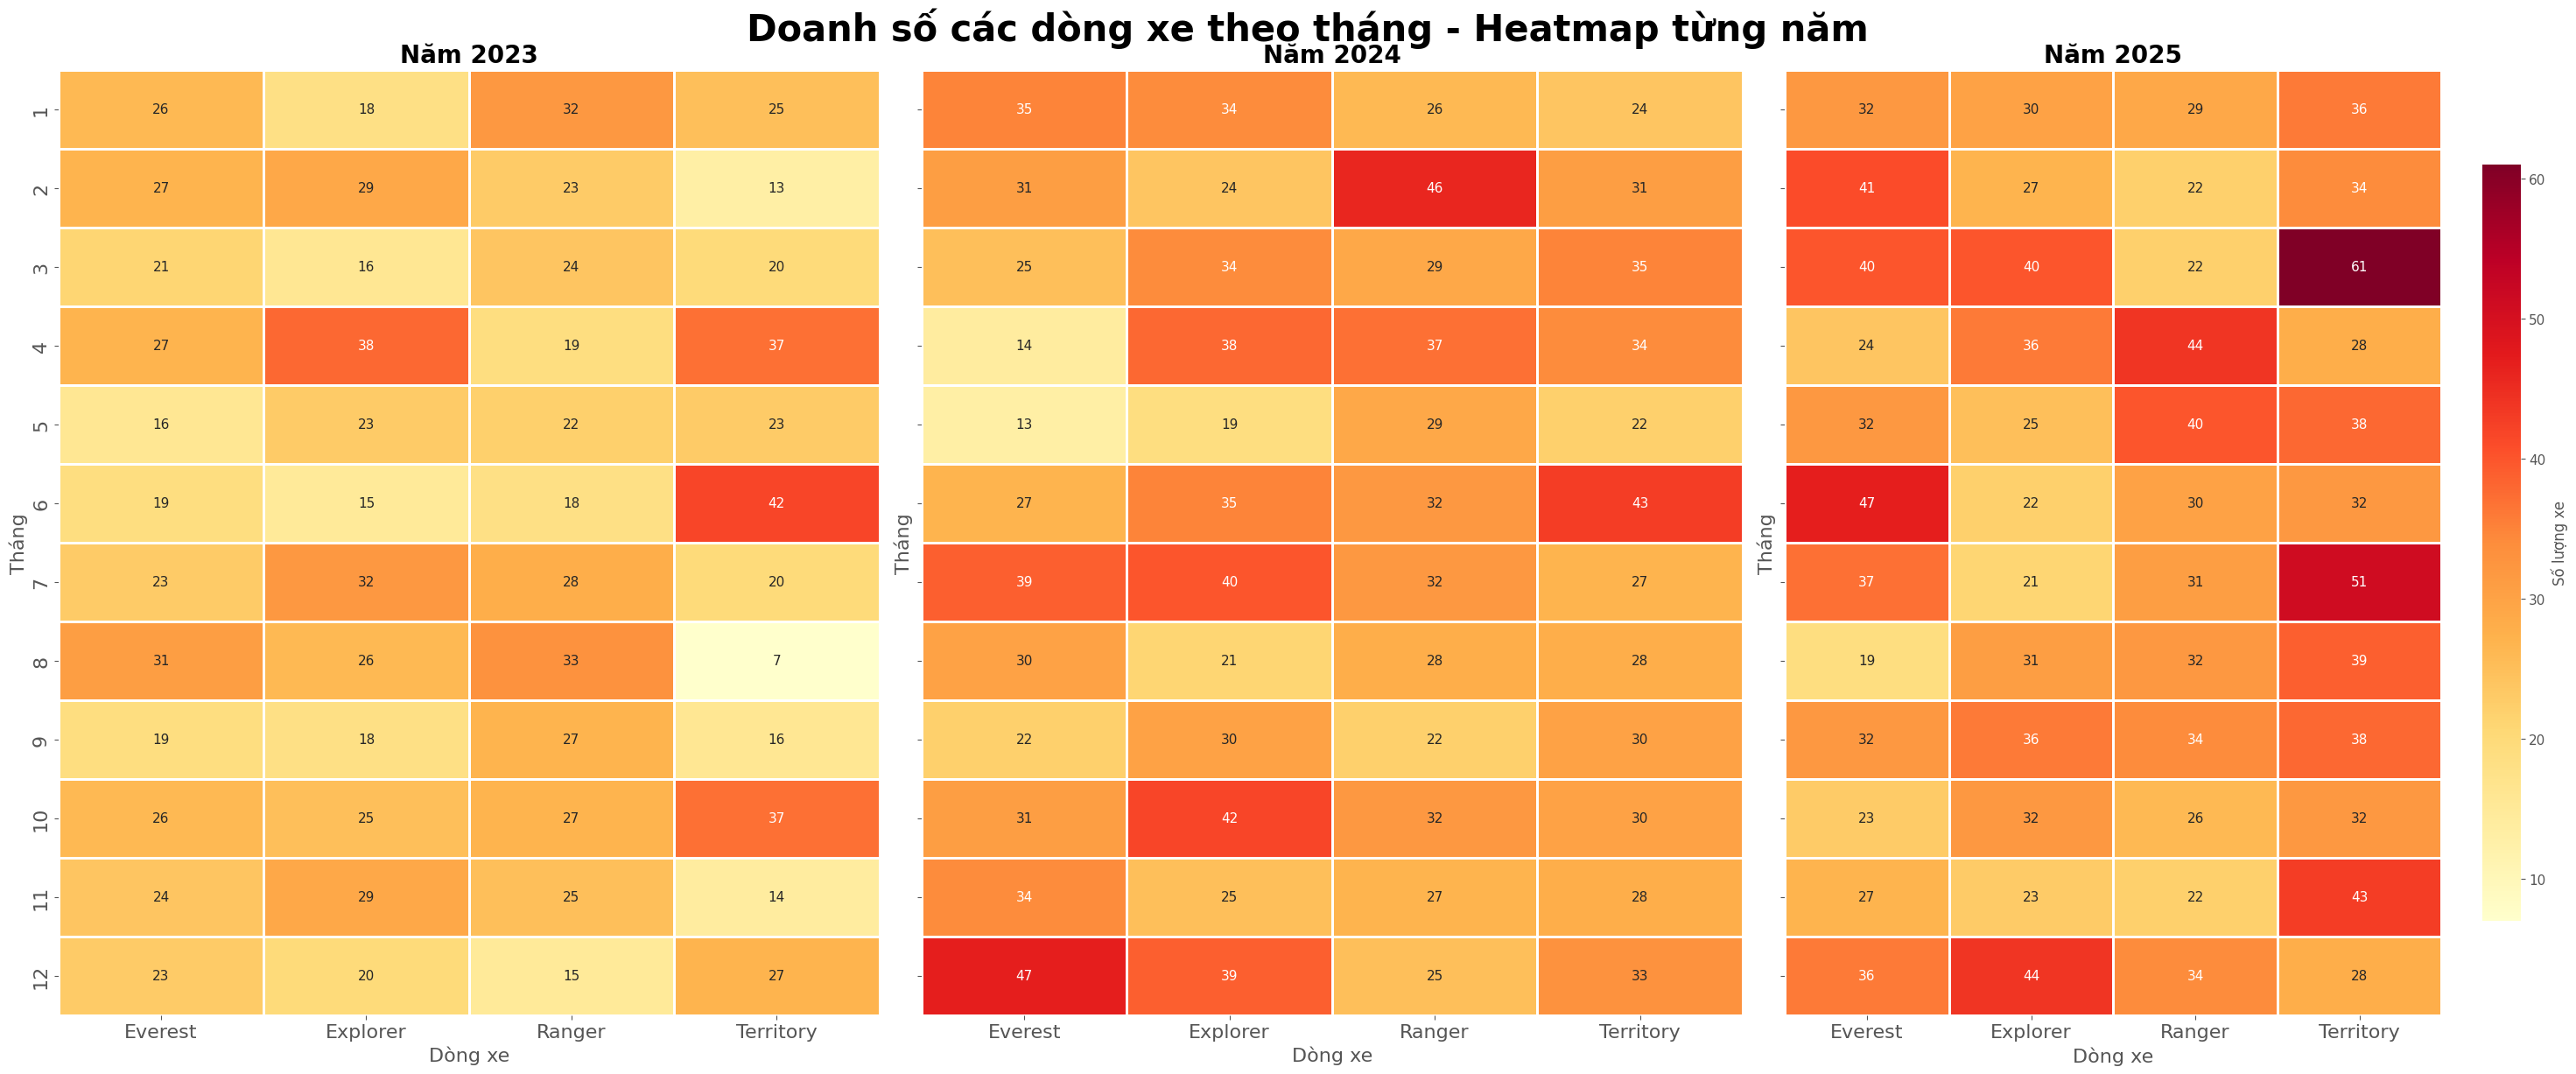

In [10]:
# Mục đích: Dùng heatmap để nhìn mật độ bán hàng theo (tháng, dòng xe) riêng từng năm
sales_model_month_year = df.groupby(['Năm', 'Tháng', 'Dòng xe'], as_index=False)['Số lượng (xe)'].sum()

fig, axes = plt.subplots(1, 3, figsize=(30, 12), sharey=True)  
years = sorted(sales_model_month_year['Năm'].unique())

# Thang màu chung
vmin = sales_model_month_year['Số lượng (xe)'].min()
vmax = sales_model_month_year['Số lượng (xe)'].max()

for i, year in enumerate(years):
    df_year = sales_model_month_year[sales_model_month_year['Năm'] == year]
    pivot = df_year.pivot(index='Tháng', columns='Dòng xe', values='Số lượng (xe)').fillna(0)
    
    sns.heatmap(
        pivot,
        annot=True,
        fmt='.0f',
        cmap='YlOrRd',
        linewidths=1,           
        linecolor='white',
        vmin=vmin, vmax=vmax,
        cbar=(i == 2),          
        cbar_kws={'label': 'Số lượng xe', 'shrink': 0.8},
        ax=axes[i]
    )
    axes[i].set_title(f'Năm {year}', fontsize=20, weight='bold')
    axes[i].set_xlabel('Dòng xe', fontsize=16)
    axes[i].set_ylabel('Tháng', fontsize=16)
    axes[i].tick_params(axis='both', labelsize=16)

plt.tight_layout()
plt.suptitle('Doanh số các dòng xe theo tháng - Heatmap từng năm', fontsize=30, weight='bold', y=1.02)
plt.show()

### Insights - Biểu đồ 4
- Điểm nổi bật: Mỗi dòng xe có nhịp tăng/giảm theo tháng khác nhau giữa các năm.
- Xu hướng chính: Một số dòng xe thể hiện tính mùa vụ rõ (tháng cao điểm lặp lại).
- Nguyên nhân có thể: Khác biệt chiến dịch bán hàng, nguồn cung, thời điểm ra phiên bản mới.
- Đề xuất hành động: Lập kế hoạch tồn kho và ưu đãi theo tháng cho từng dòng xe, theo từng năm.

## Biểu đồ 5 - Doanh số theo dòng xe (Bar Chart)

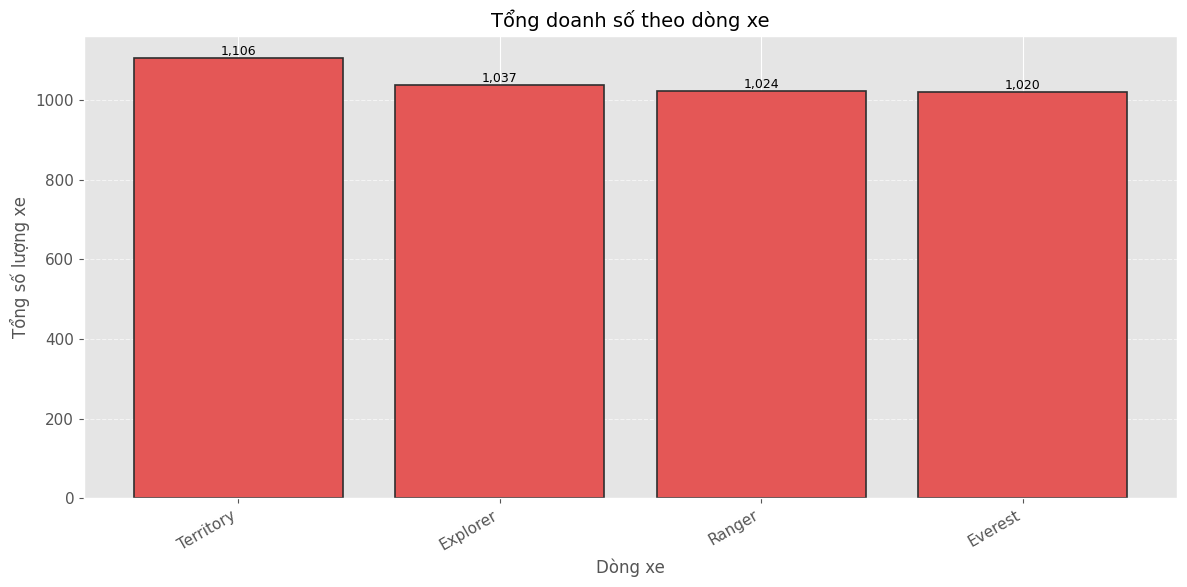

In [11]:
# Mục đích: Cộng gộp doanh số theo từng dòng xe, sắp xếp giảm dần và vẽ bar chart để xác định nhóm sản phẩm chủ lực đóng góp lớn nhất.
sales_by_model = (
    df.groupby('Dòng xe', as_index=False)['Số lượng (xe)']
      .sum()
      .sort_values('Số lượng (xe)', ascending=False)
)
fig, ax = plt.subplots(figsize=(12, 6))
bars = ax.bar(sales_by_model['Dòng xe'], sales_by_model['Số lượng (xe)'], color='#E45756', edgecolor='#2F2F2F', linewidth=1.2)
ax.set_title('Tổng doanh số theo dòng xe')
ax.set_xlabel('Dòng xe')
ax.set_ylabel('Tổng số lượng xe')
ax.grid(True, axis='y', linestyle='--', alpha=0.6)
plt.xticks(rotation=30, ha='right')
for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, height, f'{int(height):,}', ha='center', va='bottom', fontsize=9)
plt.tight_layout()
plt.show()

### Insights - Biểu đồ 5
- Điểm nổi bật: Chênh lệch doanh số giữa các dòng xe rõ ràng.
- Xu hướng chính: Một nhóm nhỏ dòng xe đóng góp lớn doanh số.
- Nguyên nhân có thể: Độ phù hợp nhu cầu và lợi thế cạnh tranh.
- Đề xuất hành động: Ưu tiên tồn kho dòng chủ lực, kích cầu dòng yếu.

## Biểu đồ 6 - Top 3 dòng xe (Bar Chart)
Không tạo biểu đồ top khách hàng.

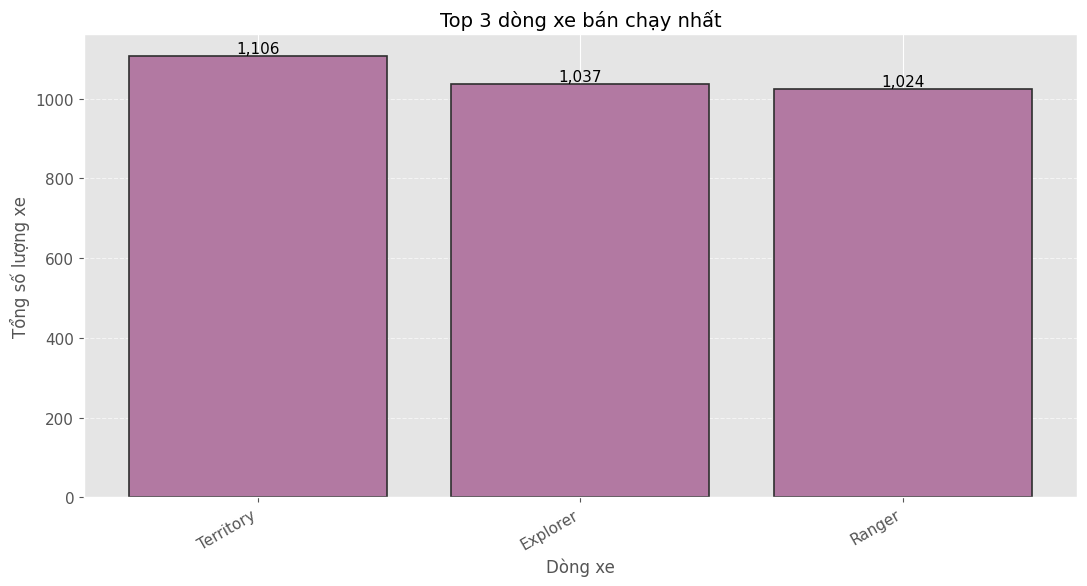

In [12]:
# Mục đích: Trích xuất 3 dòng xe có doanh số cao nhất từ bảng đã sắp xếp và vẽ biểu đồ cột riêng để nhấn mạnh nhóm bán chạy nhất.
top_3_models = sales_by_model.head(3)
fig, ax = plt.subplots()
bars = ax.bar(top_3_models['Dòng xe'], top_3_models['Số lượng (xe)'], color='#B279A2', edgecolor='#2F2F2F', linewidth=1.2)
ax.set_title('Top 3 dòng xe bán chạy nhất')
ax.set_xlabel('Dòng xe')
ax.set_ylabel('Tổng số lượng xe')
ax.grid(True, axis='y', linestyle='--', alpha=0.6)
plt.xticks(rotation=30, ha='right')
for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, height, f'{int(height):,}', ha='center', va='bottom')
plt.tight_layout()
plt.show()

### Insights - Biểu đồ 6
- Điểm nổi bật: Top 3 dòng xe chiếm tỷ trọng cao trong tổng doanh số.
- Xu hướng chính: Mức độ tập trung doanh số vào nhóm dẫn dắt lớn.
- Nguyên nhân có thể: Giá trị sản phẩm và độ phủ kênh bán.
- Đề xuất hành động: Bảo vệ nhóm top 3 và phát triển nhóm kế cận để giảm rủi ro phụ thuộc.

## Biểu đồ 7 - Tỷ trọng dòng xe (Pie Chart)

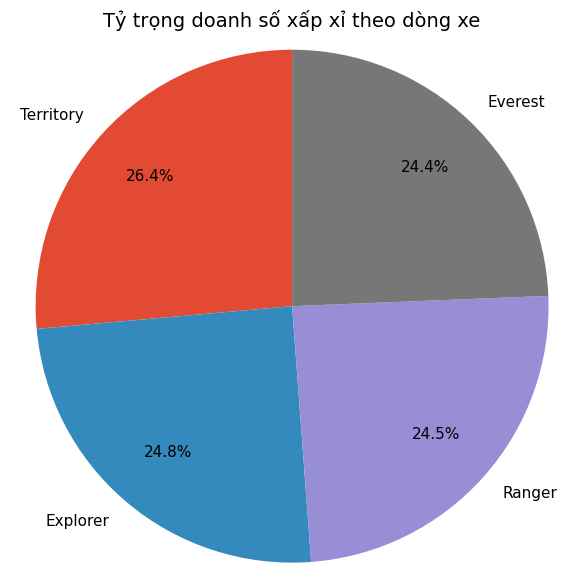

In [18]:
# Mục đích: Biểu diễn cơ cấu tỷ trọng doanh số giữa các dòng xe bằng pie chart để đánh giá mức độ tập trung danh mục sản phẩm.
fig, ax = plt.subplots(figsize=(6, 6))
ax.pie(sales_by_model['Số lượng (xe)'], labels=sales_by_model['Dòng xe'], autopct='%1.1f%%', startangle=90, pctdistance=0.75)
ax.set_title('Tỷ trọng doanh số xấp xỉ theo dòng xe')
ax.axis('equal')
plt.tight_layout()
plt.show()

### Insights - Biểu đồ 7
- Điểm nổi bật: Cơ cấu dòng xe chưa đồng đều, phụ thuộc vào vài dòng lớn.
- Xu hướng chính: Đa dạng doanh thu giữa các dòng còn hạn chế.
- Nguyên nhân có thể: Chiến lược danh mục và hành vi tiêu dùng theo phân khúc.
- Đề xuất hành động: Tối ưu danh mục, tăng đóng góp của nhóm dòng xe tầm trung.

## Biểu đồ 8 - Doanh số theo màu sắc (Bar Chart)

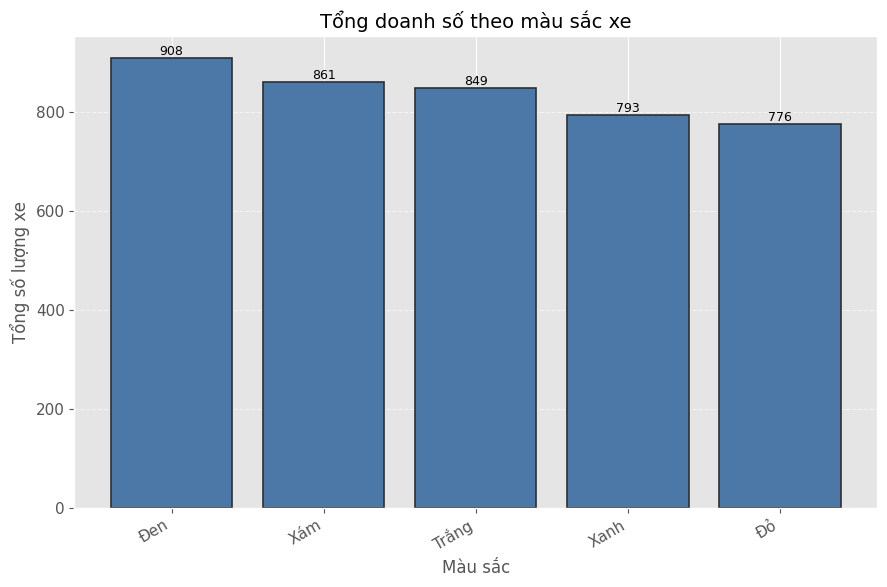

In [19]:
# Mục đích: Tổng hợp số xe bán theo màu sắc, sắp xếp giảm dần và vẽ cột so sánh nhằm quan sát thị hiếu màu xe của khách hàng.
sales_by_color = (
    df.groupby('Màu', as_index=False)['Số lượng (xe)']
      .sum()
      .sort_values('Số lượng (xe)', ascending=False)
)
fig, ax = plt.subplots(figsize=(9, 6))
bars = ax.bar(sales_by_color['Màu'], sales_by_color['Số lượng (xe)'], color='#4C78A8', edgecolor='#2F2F2F', linewidth=1.2)
ax.set_title('Tổng doanh số theo màu sắc xe')
ax.set_xlabel('Màu sắc')
ax.set_ylabel('Tổng số lượng xe')
ax.grid(True, axis='y', linestyle='--', alpha=0.6)
plt.xticks(rotation=30, ha='right')
for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, height, f'{int(height):,}', ha='center', va='bottom', fontsize=9)
plt.tight_layout()
plt.show()

### Insights - Biểu đồ 8
- Điểm nổi bật: Màu xe có phân hóa doanh số rõ ràng.
- Xu hướng chính: Màu trung tính thường bán tốt hơn.
- Nguyên nhân có thể: Thị hiếu số đông, giá trị bán lại, độ sẵn hàng.
- Đề xuất hành động: Điều chỉnh tồn kho màu theo lịch sử bán và theo khu vực.

## 3. Phân tích khu vực

## Biểu đồ 9 - Doanh số theo khu vực (Bar Chart)

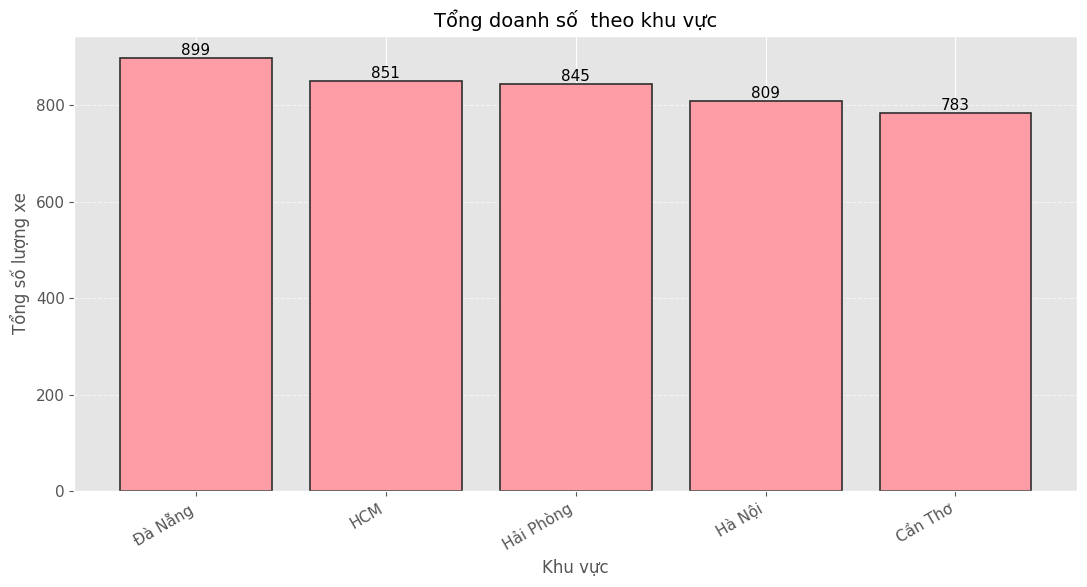

In [15]:
# Mục đích: Tính tổng doanh số theo khu vực và trực quan hóa bằng biểu đồ cột để xác định khu vực trọng điểm và khu vực còn dư địa tăng trưởng.
sales_by_region = (
    df.groupby('Khu vực', as_index=False)['Số lượng (xe)']
      .sum()
      .sort_values('Số lượng (xe)', ascending=False)
)
fig, ax = plt.subplots()
bars = ax.bar(sales_by_region['Khu vực'], sales_by_region['Số lượng (xe)'], color='#FF9DA6', edgecolor='#2F2F2F', linewidth=1.2)
ax.set_title('Tổng doanh số  theo khu vực')
ax.set_xlabel('Khu vực')
ax.set_ylabel('Tổng số lượng xe')
ax.grid(True, axis='y', linestyle='--', alpha=0.6)
plt.xticks(rotation=30, ha='right')
for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, height, f'{int(height):,}', ha='center', va='bottom')
plt.tight_layout()
plt.show()

### Insights - Biểu đồ 9
- Điểm nổi bật: Có khu vực vượt trội doanh số so với phần còn lại.
- Xu hướng chính: Khu vực trọng điểm và khu vực tiềm năng tách biệt khá rõ.
- Nguyên nhân có thể: Mật độ đại lý, sức mua địa phương, mức cạnh tranh.
- Đề xuất hành động: Phân bổ ngân sách theo hiệu suất khu vực và mở rộng kênh ở vùng tiềm năng.

## Biểu đồ 10 - So sánh khu vực theo năm (Grouped Bar)

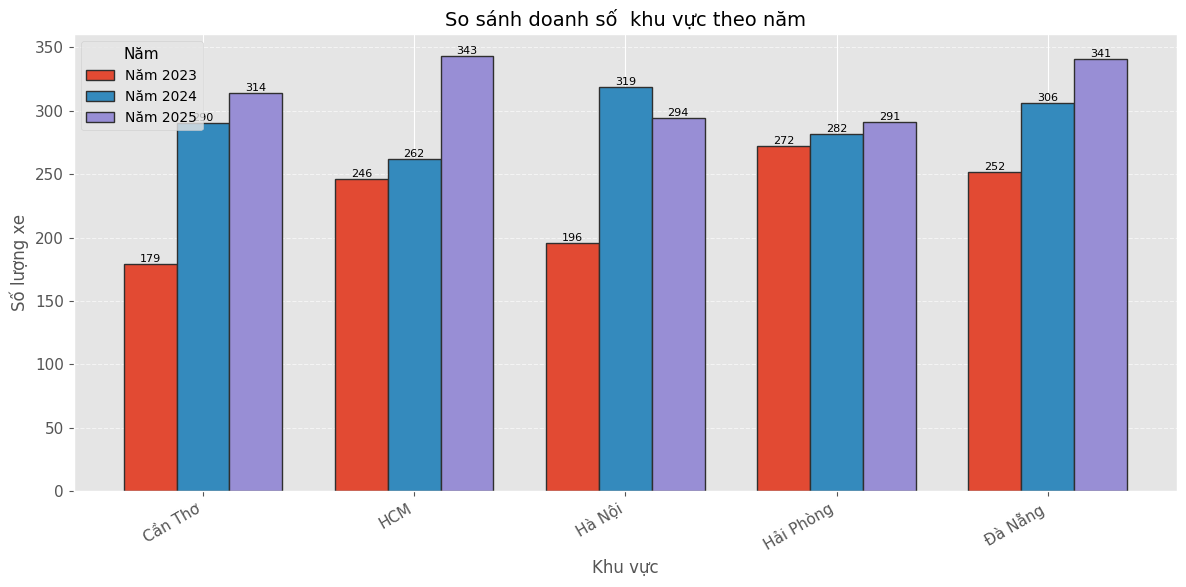

In [16]:
# Mục đích: So sánh đóng góp doanh số của từng khu vực theo từng năm bằng grouped bar chart để nhìn rõ xu hướng dịch chuyển thị trường theo thời gian.
region_year = df.groupby(['Khu vực', 'Năm'], as_index=False)['Số lượng (xe)'].sum()
pivot_region_year = region_year.pivot(index='Khu vực', columns='Năm', values='Số lượng (xe)').fillna(0)
fig, ax = plt.subplots(figsize=(12, 6))
x = range(len(pivot_region_year.index))
bar_width = 0.25
years = list(pivot_region_year.columns)
for i, year in enumerate(years):
    positions = [p + i * bar_width for p in x]
    values = pivot_region_year[year].values
    bars = ax.bar(positions, values, width=bar_width, label=f'Năm {year}', edgecolor='#2F2F2F', linewidth=1.0)
    for bar in bars:
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2, h, f'{int(h):,}', ha='center', va='bottom', fontsize=8)
ax.set_title('So sánh doanh số  khu vực theo năm')
ax.set_xlabel('Khu vực')
ax.set_ylabel('Số lượng xe')
ax.set_xticks([p + bar_width for p in x])
ax.set_xticklabels(pivot_region_year.index, rotation=30, ha='right')
ax.legend(title='Năm')
ax.grid(True, axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

### Insights - Biểu đồ 10
- Điểm nổi bật: Mức tăng/giảm qua năm khác nhau theo từng khu vực.
- Xu hướng chính: Có sự dịch chuyển đóng góp khu vực theo thời gian.
- Nguyên nhân có thể: Chính sách bán hàng địa phương, nguồn cung, mức cạnh tranh.
- Đề xuất hành động: Tối ưu phân bổ nguồn lực theo khu vực đóng góp cao và khu vực cần kích hoạt.

## 4. Dự báo ngắn hạn

## Biểu đồ 11 - Dự báo ngắn hạn bằng Holt-Winters

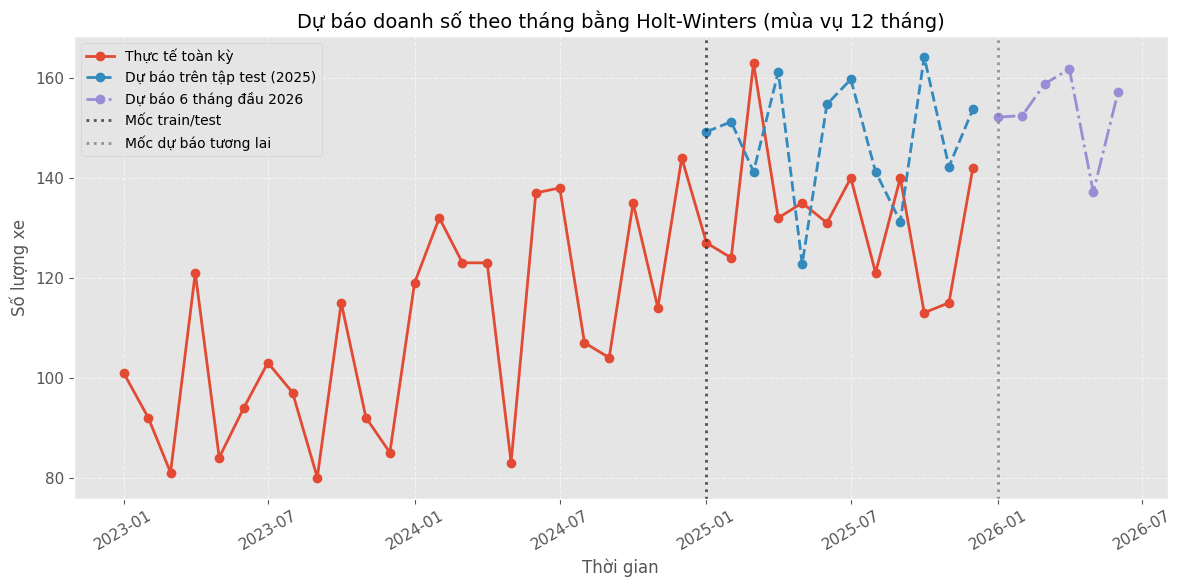

RMSE trên tập kiểm tra năm 2025: 25.27 xe


,Tháng dự báo,Doanh số xấp xỉ (số xe)
0,2026-01,152
1,2026-02,153
2,2026-03,159
3,2026-04,162
4,2026-05,137
5,2026-06,157


In [17]:
# Mục đích: Tạo chuỗi thời gian theo tháng, chia tập huấn luyện/kiểm tra (2023-2024/2025),
# huấn luyện Holt-Winters, tính RMSE đánh giá sai số và dự báo 6 tháng tiếp theo.

# 1) Tổng hợp số lượng xe theo từng tháng để tạo chuỗi thời gian đầu vào cho mô hình.
monthly_sales = (
    df.groupby(['Năm', 'Tháng'], as_index=False)['Số lượng (xe)']
      .sum()
      .sort_values(['Năm', 'Tháng'])
)

# 2) Tạo cột ngày chuẩn dạng tháng-bắt đầu (MS: Month Start).
monthly_sales['Ngày'] = pd.to_datetime(
    monthly_sales['Năm'].astype(int).astype(str) + '-' +
    monthly_sales['Tháng'].astype(int).astype(str) + '-01',
    format='%Y-%m-%d'
)

# 3) Đặt cột ngày làm index và ép tần suất theo tháng để mô hình nhận dữ liệu đều thời gian.
ts = monthly_sales.set_index('Ngày')['Số lượng (xe)'].asfreq('MS')

# 4) Chia dữ liệu: train = 2023-2024, test = 2025.
train = ts['2023-01-01':'2024-12-01']
test = ts['2025-01-01':'2025-12-01']

# 5) Huấn luyện Holt-Winters trên tập train (trend + mùa vụ cộng, chu kỳ 12 tháng).
hw_model = ExponentialSmoothing(
    train,
    trend='add',
    seasonal='add',
    seasonal_periods=12,
    initialization_method='estimated'
).fit(optimized=True)

# 6) Dự báo trên tập test để đánh giá chất lượng mô hình bằng RMSE.
test_forecast = hw_model.forecast(len(test))
rmse = np.sqrt(np.mean((test - test_forecast) ** 2))

# 7) Fit lại mô hình trên toàn bộ dữ liệu đến hết 2025 để dự báo tương lai.
hw_model_all = ExponentialSmoothing(
    ts,
    trend='add',
    seasonal='add',
    seasonal_periods=12,
    initialization_method='estimated'
).fit(optimized=True)

# 8) Dự báo 6 tháng tiếp theo (tháng 01/2026 đến 06/2026).
future_forecast = hw_model_all.forecast(6)

# 9) Vẽ cùng lúc dữ liệu thực tế, dự báo trên test và dự báo tương lai để so sánh trực quan.
fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(ts.index, ts.values, marker='o', label='Thực tế toàn kỳ')
ax.plot(test.index, test_forecast.values, marker='o', linestyle='--', label='Dự báo trên tập test (2025)')
ax.plot(future_forecast.index, future_forecast.values, marker='o', linestyle='-.', label='Dự báo 6 tháng đầu 2026')

# 10) Thêm các mốc dọc để phân tách giai đoạn train/test và giai đoạn dự báo tương lai.
ax.axvline(pd.Timestamp('2025-01-01'), color='#2F2F2F', linestyle=':', alpha=0.8, label='Mốc train/test')
ax.axvline(pd.Timestamp('2026-01-01'), color='#7F7F7F', linestyle=':', alpha=0.8, label='Mốc dự báo tương lai')

ax.set_title('Dự báo doanh số theo tháng bằng Holt-Winters (mùa vụ 12 tháng)')
ax.set_xlabel('Thời gian')
ax.set_ylabel('Số lượng xe')
ax.grid(True, linestyle='--', alpha=0.6)
ax.legend()
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

# 11) In RMSE để định lượng sai số dự báo trên tập test.
print(f'RMSE trên tập kiểm tra năm 2025: {rmse:.2f} xe')

# 12) Xuất bảng dự báo 6 tháng tới để tiện dùng cho báo cáo/kế hoạch.
forecast_df = pd.DataFrame({
    'Tháng dự báo': future_forecast.index.strftime('%Y-%m'),
    'Doanh số xấp xỉ (số xe)': np.round(future_forecast.values, 0).astype(int)
})
display(forecast_df)

### Insights - Biểu đồ 11
- Điểm nổi bật: Holt-Winters mô phỏng xu hướng + mùa vụ tốt hơn hồi quy tuyến tính.
- Xu hướng chính: RMSE trên test 2025 phản ánh độ tin cậy ngắn hạn của mô hình.
- Nguyên nhân ảnh hưởng độ chính xác: Biến động bất thường về khuyến mại, nguồn cung, thị trường.
- Đề xuất hành động: Dùng dự báo làm baseline và cập nhật mô hình mỗi tháng.

## Kết luận tổng thể
- Theo thời gian: Doanh số biến động theo tháng/quý và có dấu hiệu mùa vụ.
- Theo sản phẩm: Doanh số tập trung vào một số dòng xe chủ lực.
- Theo khu vực: Có sự chênh lệch đáng kể giữa các vùng thị trường.
- Theo dự báo: Holt-Winters phù hợp cho dự báo ngắn hạn có tính mùa vụ.

### Khuyến nghị
1. Lập kế hoạch tồn kho và marketing theo mùa vụ tháng/quý.
2. Ưu tiên ngân sách cho dòng xe và khu vực hiệu quả cao.
3. Theo dõi RMSE định kỳ và tái huấn luyện mô hình khi có dữ liệu mới.
4. Bổ sung dữ liệu giá bán/khuyến mại/tồn kho để nâng cấp dự báo doanh thu thực tế.